<a href="https://colab.research.google.com/github/CamFuenzalidaC/GuerrerosZ/blob/main/Primera_evaluacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nombre de integrantes: David Salvatierra Y Camilo Fuenzalida
seccion:003D

FUENTE DE INFORMACION: https://www.kaggle.com/datasets/anbudanadithya/spotify-music?resource=download

Contexto :  Spotify se ha posicionado como una de las aplicaciones de streaming más utilizadas a nivel mundial, recopilando millones de datos sobre canciones, artistas, géneros musicales y preferencias de los usuarios.

Gracias a esta gran cantidad de información, es posible aplicar técnicas de análisis de datos y Machine Learning para descubrir patrones ocultos dentro de la música. Variables como la popularidad de una canción, su energía, ritmo, duración, nivel acústico o danceability permiten estudiar qué características influyen en el éxito musical o cómo se relacionan los distintos géneros entre sí.

En esta investigación se tratara con un conjunto de datos de Spotify que contiene información de aproximadamente 114.000 canciones, incluyendo atributos musicales y datos relevantes como nombre del artista, álbum, género y nivel de popularidad.

El objetivo principal será analizar este dataset utilizando herramientas de ciencia de datos y algoritmos de aprendizaje automático, con el fin de:

Clasificar la energia de la cancion con el volumen de la misma .
Poder detectar la acustica del genero y ver cual es el mas acustico
Ver la relacion entres intrumental y el volumen del genero.

Con este proyecto podremos a prueba todo lo estudiado en un contexto donde podemos ver datos  gruesos y poder trabajar con ellos y sacar la informacion esencial que queremos mostrar para el receptor que este contemplado esta data para poder darle una informacion mas limpia y agradable visualmente.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [27]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas
pd.set_option('display.max_rows', None)

In [28]:
url = "https://raw.githubusercontent.com/CamFuenzalidaC/GuerrerosZ/ce340033c05f2b38c72ffdbfad7d39d310892e07/Spotify_Music.csv"
df = pd.read_csv(url,index_col=0)

In [29]:
df.head(5)#los primeros 5

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Se observan las primeras filas del dataset, lo que permite identificar la estructura de los datos, los nombres de las columnas y el tipo de información contenida en cada una. Esto facilita una comprensión inicial antes de realizar análisis más profundos.

In [30]:
df.tail(5) #podemos ver los ultimos 5 registros del dataset

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.235,5,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.117,0,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.329,0,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.506,7,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,0.487,1,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [31]:
df.shape # contas filas y columnas

(114000, 20)

El dataset contiene una cantidad considerable de filas y columnas, lo que indica que es un conjunto de datos amplio. Esto es adecuado para realizar análisis estadísticos y aplicar modelos de machine learning en etapas posteriores.

In [32]:
df.columns #mostramos los nombres de las columnas

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

MAPEO DE DATOS:

track_id: Categórico Nominal

artists: Categórico Nominal

album_name: Categórico Nominal

track_name: Categórico Nominal

popularity: Numérico Discreto

duration_ms: Numérico Discreto

explicit: Categórico Binario

danceability: Numérico Continuo

energy: Numérico Continuo

key: Categórico Ordinal

loudness: Numérico Continuo

mode: Categórico Binario

speechiness: Numérico Continuo

acousticness: Numérico Continuo

instrumentalness: Numérico Continuo

liveness: Numérico Continuo

valence: Numérico Continuo

tempo: Numérico Continuo

time_signature: Numérico Discreto

track_genre: Categórico Nominal

Clasificación de Variables

Categórico Nominal: Categorías sin un orden o jerarquía específica.
Ejemplo: artista, nombre del álbum, género musical.

Categórico Ordinal: Categorías que siguen un orden lógico o escala.
Ejemplo: tonalidad musical representada por notas (C, D, E, F, G, A, B).

Categórico Binario: Variable con solo dos categorías posibles.
Ejemplo: explícita (Sí/No), modo musical (Mayor/Menor).

Numérico Discreto: Valores que surgen de un conteo o se expresan en números enteros.
Ejemplo: popularidad, duración en milisegundos, compás musical.

Numérico Continuo: Valores que resultan de una medición y pueden tener decimales infinitos.
Ejemplo: energía, tempo, loudness, danceability.

In [33]:
cant_cat_genero = df['track_genre'].value_counts()
print(cant_cat_genero)

# cantidad total de categorías únicas
print(f"cantidad géneros: {cant_cat_genero.count()}")

track_genre
acoustic             1000
afrobeat             1000
alt-rock             1000
alternative          1000
ambient              1000
anime                1000
black-metal          1000
bluegrass            1000
blues                1000
brazil               1000
breakbeat            1000
british              1000
cantopop             1000
chicago-house        1000
children             1000
chill                1000
classical            1000
club                 1000
comedy               1000
country              1000
dance                1000
dancehall            1000
death-metal          1000
deep-house           1000
detroit-techno       1000
disco                1000
disney               1000
drum-and-bass        1000
dub                  1000
dubstep              1000
edm                  1000
electro              1000
electronic           1000
emo                  1000
folk                 1000
forro                1000
french               1000
funk                 1000


Tenemos 114 categorías de géneros musicales distintas en la variable track_genre.

In [34]:
cant_cat_artists = df['artists'].value_counts()

# Mostrar los 50 artistas más repetidos
print(cant_cat_artists.head(50))

# Cantidad total de artistas únicos
print(f"cantidad artistas únicos: {cant_cat_artists.count()}")

artists
The Beatles                       279
George Jones                      271
Stevie Wonder                     236
Linkin Park                       224
Ella Fitzgerald                   222
Prateek Kuhad                     217
Feid                              202
Chuck Berry                       190
Håkan Hellström                   183
OneRepublic                       181
The Beach Boys                    176
my little airport                 171
Elvis Presley                     169
Charlie Brown Jr.                 169
Red Hot Chili Peppers             159
Bryan Adams                       157
Scooter                           155
Daddy Yankee                      154
Arctic Monkeys                    152
BTS                               151
Norah Jones                       150
The Prophet                       145
Hank Williams                     140
Glee Cast                         139
Don Omar                          137
Vybz Kartel                       128
Los 

La variable artists presenta una gran cantidad de categorías únicas, por lo que sola mente mostraremos los 50 artistas con mayor frecuencia dentro del data set

In [35]:
df.dtypes

,0
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64
key,int64


Mediante df.dtypes se observan los tipos de datos de cada columna, lo que permite clasificar las variables y preparar correctamente el análisis de datos.

In [36]:
df.isna().sum() # cuenta los nulos totales

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0



Se utiliza df.isna().sum() para identificar la cantidad de valores nulos presentes en cada variable del dataset.

In [37]:
df[df.isnull().any(axis=1)] #detectar la fila nula

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


Se identifican los valores nulos presentes en el dataset. Esto permite evaluar la calidad de los datos y determinar si es necesario aplicar técnicas de limpieza para evitar errores o sesgos en el análisis.

In [38]:
df=df.dropna()

Se utiliza df.dropna() para eliminar las filas que contienen valores nulos en el dataset.

In [39]:
df.isna().sum()

,0
track_id,0
artists,0
album_name,0
track_name,0
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


Se procede a la limpieza del dataset eliminando los valores nulos. Esto permite trabajar con datos completos y confiables, evitando inconsistencias en los resultados del análisis.

In [40]:
import pandas as pd

def tipo_analitico(col):
    if pd.api.types.is_numeric_dtype(col):
        return 'Numerico'
    else:
        return 'Categorico'

summary = pd.DataFrame({
    'tipo_dato': df.dtypes,
    'nulos': df.isnull().sum(),
    'n_unicos': df.nunique(),
    'tipo_analitico': df.apply(tipo_analitico)
})

summary #veremos los tipos de datos, los nulos (no deberia haber nigun nulo)
#y los  valores unicos tambien los tipos de valores que puede tener ya sea
#categoricos o numericos

,tipo_dato,nulos,n_unicos,tipo_analitico
track_id,object,0,89740,Categorico
artists,object,0,31437,Categorico
album_name,object,0,46589,Categorico
track_name,object,0,73608,Categorico
popularity,int64,0,101,Numerico
duration_ms,int64,0,50696,Numerico
explicit,bool,0,2,Numerico
danceability,float64,0,1174,Numerico
energy,float64,0,2083,Numerico
key,int64,0,12,Numerico


Se observan los tipos de datos de cada columna, identificando variables numéricas y categóricas. Esta distinción es importante para seleccionar las técnicas de análisis adecuadas y preparar los datos para futuros modelos predictivos.

Estadistica descriptiva a las variables

In [41]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Se presentan estadísticas descriptivas de las variables numéricas, como promedio, valores mínimos y máximos. Esto permite entender la distribución de los datos y detectar posibles valores atípicos.


In [42]:
pip install category_encoders

In [43]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce
import pandas as pd

# 1. OneHotEncoder para 'track_genre' (Equivalente a Región)
# Usamos One-Hot porque los géneros son categorías sin un orden específico
ohe = OneHotEncoder(sparse_output=False)
genre_encoded = ohe.fit_transform(df[['track_genre']])

# Convertimos a DataFrame con nombres de columnas claros
genre_df = pd.DataFrame(
    genre_encoded,
    columns=ohe.get_feature_names_out(['track_genre']),
    index=df.index
)

# 2. Binary Encoding para 'artists' (Equivalente a Comuna)
# Como hay miles de artistas, el Binary Encoding evita crear miles de columnas
# (lo cual agotaría tu memoria RAM), resumiéndolas en una representación binaria.
be = ce.BinaryEncoder(cols=['artists'])
artists_binary = be.fit_transform(df[['artists']])

# 3. Concatenar todo y eliminar las columnas originales
# Mantenemos las variables numéricas (popularidad, energía, etc.) y pegamos las nuevas
# Eliminamos track_id, track_name y album_name ya que suelen ser identificadores únicos
# que no ayudan a la predicción general, a menos que decidas procesarlas también.
cols_to_drop = ['track_id', 'artists', 'track_name', 'album_name', 'track_genre']
df_final = pd.concat([df.drop(columns=cols_to_drop), genre_df, artists_binary], axis=1)

# 4. Ver los cambios
print("Primeras filas del nuevo dataset:")
print(df_final.head())
print(f"\nTotal de columnas finales: {len(df_final.columns)}")

Primeras filas del nuevo dataset:
   popularity  duration_ms  explicit  danceability  energy  key  loudness  \
0          73       230666     False         0.676  0.4610    1    -6.746   
1          55       149610     False         0.420  0.1660    1   -17.235   
2          57       210826     False         0.438  0.3590    0    -9.734   
3          71       201933     False         0.266  0.0596    0   -18.515   
4          82       198853     False         0.618  0.4430    2    -9.681   

   mode  speechiness  acousticness  instrumentalness  liveness  valence  \
0     0       0.1430        0.0322          0.000001    0.3580    0.715   
1     1       0.0763        0.9240          0.000006    0.1010    0.267   
2     1       0.0557        0.2100          0.000000    0.1170    0.120   
3     1       0.0363        0.9050          0.000071    0.1320    0.143   
4     1       0.0526        0.4690          0.000000    0.0829    0.167   

     tempo  time_signature  track_genre_acoustic  tr

In [44]:
df_final.head(100) #observamos el nuevo dataframe con las variables y encoder aplicado



,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre_acoustic,track_genre_afrobeat,track_genre_alt-rock,track_genre_alternative,track_genre_ambient,track_genre_anime,track_genre_black-metal,track_genre_bluegrass,track_genre_blues,track_genre_brazil,track_genre_breakbeat,track_genre_british,track_genre_cantopop,track_genre_chicago-house,track_genre_children,track_genre_chill,track_genre_classical,track_genre_club,track_genre_comedy,track_genre_country,track_genre_dance,track_genre_dancehall,track_genre_death-metal,track_genre_deep-house,track_genre_detroit-techno,track_genre_disco,track_genre_disney,track_genre_drum-and-bass,track_genre_dub,track_genre_dubstep,track_genre_edm,track_genre_electro,track_genre_electronic,track_genre_emo,track_genre_folk,track_genre_forro,track_genre_french,track_genre_funk,track_genre_garage,track_genre_german,track_genre_gospel,track_genre_goth,track_genre_grindcore,track_genre_groove,track_genre_grunge,track_genre_guitar,track_genre_happy,track_genre_hard-rock,track_genre_hardcore,track_genre_hardstyle,track_genre_heavy-metal,track_genre_hip-hop,track_genre_honky-tonk,track_genre_house,track_genre_idm,track_genre_indian,track_genre_indie,track_genre_indie-pop,track_genre_industrial,track_genre_iranian,track_genre_j-dance,track_genre_j-idol,track_genre_j-pop,track_genre_j-rock,track_genre_jazz,track_genre_k-pop,track_genre_kids,track_genre_latin,track_genre_latino,track_genre_malay,track_genre_mandopop,track_genre_metal,track_genre_metalcore,track_genre_minimal-techno,track_genre_mpb,track_genre_new-age,track_genre_opera,track_genre_pagode,track_genre_party,track_genre_piano,track_genre_pop,track_genre_pop-film,track_genre_power-pop,track_genre_progressive-house,track_genre_psych-rock,track_genre_punk,track_genre_punk-rock,track_genre_r-n-b,track_genre_reggae,track_genre_reggaeton,track_genre_rock,track_genre_rock-n-roll,track_genre_rockabilly,track_genre_romance,track_genre_sad,track_genre_salsa,track_genre_samba,track_genre_sertanejo,track_genre_show-tunes,track_genre_singer-songwriter,track_genre_ska,track_genre_sleep,track_genre_songwriter,track_genre_soul,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music,artists_0,artists_1,artists_2,artists_3,artists_4,artists_5,artists_6,artists_7,artists_8,artists_9,artists_10,artists_11,artists_12,artists_13,artists_14
0,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.03220,0.000001,0.3580,0.7150,87.917,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.92400,0.000006,0.1010,0.2670,77.489,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.21000,0.000000,0.1170,0.1200,76.332,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

la librería category_encoders en Python, la cual se usa para transformar variables categóricas (texto/etiquetas) en valores numéricos para modelos de Machine Learning.

                  popularity  duration_ms  danceability    energy       key  \
popularity          1.000000    -0.007129      0.035444  0.001053 -0.003847   
duration_ms        -0.007129     1.000000     -0.073435  0.058520  0.008123   
danceability        0.035444    -0.073435      1.000000  0.134325  0.036470   
energy              0.001053     0.058520      0.134325  1.000000  0.048007   
key                -0.003847     0.008123      0.036470  0.048007  1.000000   
loudness            0.050420    -0.003475      0.259076  0.761690  0.038591   
mode               -0.013948    -0.035581     -0.069224 -0.078365 -0.135911   
speechiness        -0.044930    -0.062605      0.108625  0.142508  0.020419   
acousticness       -0.025458    -0.103770     -0.171531 -0.733908 -0.040942   
instrumentalness   -0.095147     0.124364     -0.185608 -0.181880 -0.006821   
liveness           -0.005397     0.010308     -0.131620  0.184795 -0.001597   
valence            -0.040522    -0.154464      0.477

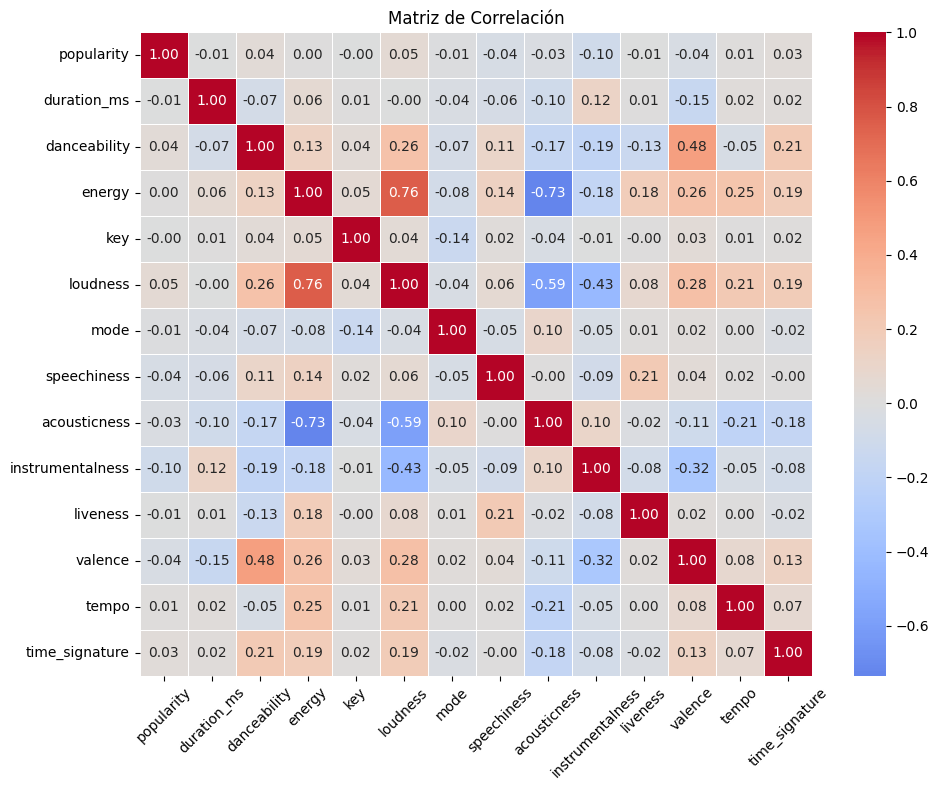

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar variables numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlación
correlacion = df_numerico.corr()

# Mostrar matriz
print(correlacion)

# Heatmap mejorado
plt.figure(figsize=(10,8))
sns.heatmap(correlacion,
            annot=True,
            fmt=".2f",      # 2 decimales
            cmap='coolwarm',
            center=0,       # centra en 0
            linewidths=0.5) # líneas entre celdas

plt.title('Matriz de Correlación')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Se presentan estadísticas descriptivas de las variables numéricas, como promedio, valores mínimos y máximos. Esto permite entender la distribución de los datos y detectar posibles valores atípicos.



El mapa de calor permite visualizar de forma gráfica la correlación entre variables. Los valores cercanos a 1 o -1 indican relaciones fuertes, mientras que los cercanos a 0 indican poca o ninguna relación.

### Interpretacion Final

A partir del análisis realizado, se concluye que existen algunas relaciones entre variables, aunque no todas presentan una correlación fuerte. Esto sugiere que el comportamiento de ciertas variables, como la popularidad, podría depender de múltiples factores. Este análisis será útil para la aplicación de modelos de machine learning en etapas posteriores.

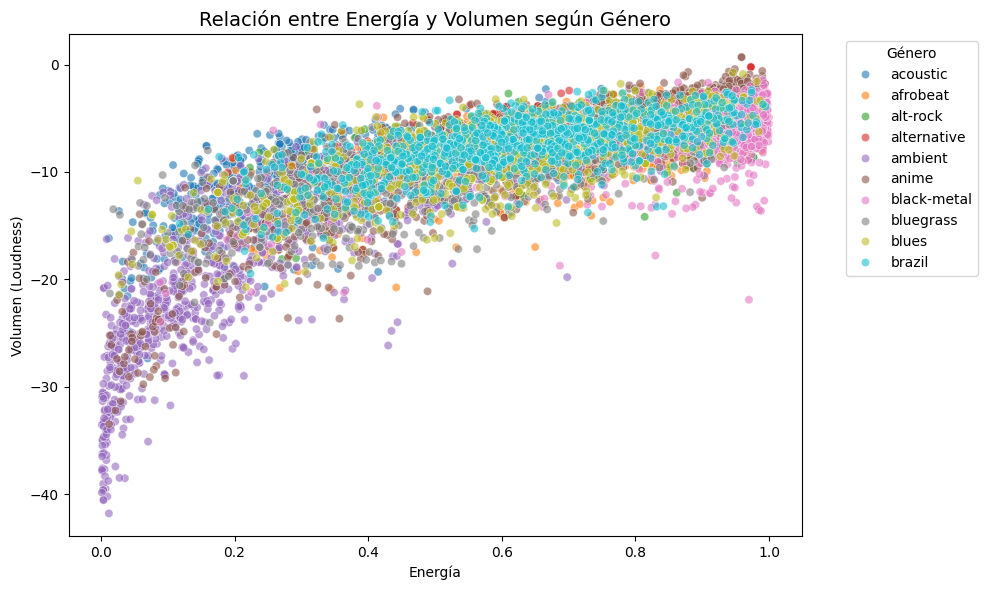

In [46]:
# Top 10 géneros más frecuentes del dataset
generos_top = df['track_genre'].value_counts().head(10).index

# Filtrar solo esos géneros
df_top10 = df[df['track_genre'].isin(generos_top)]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_top10,
    x='energy',
    y='loudness',
    hue='track_genre',
    palette='tab10',
    alpha=0.6
)

plt.title('Relación entre Energía y Volumen según Género', fontsize=14)
plt.xlabel('Energía')
plt.ylabel('Volumen (Loudness)')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Se observa que ciertos géneros tienden a concentrarse en niveles más altos de energía y volumen, mientras que otros se distribuyen en zonas más bajas, lo que evidencia diferencias en las características acústicas según el tipo de música

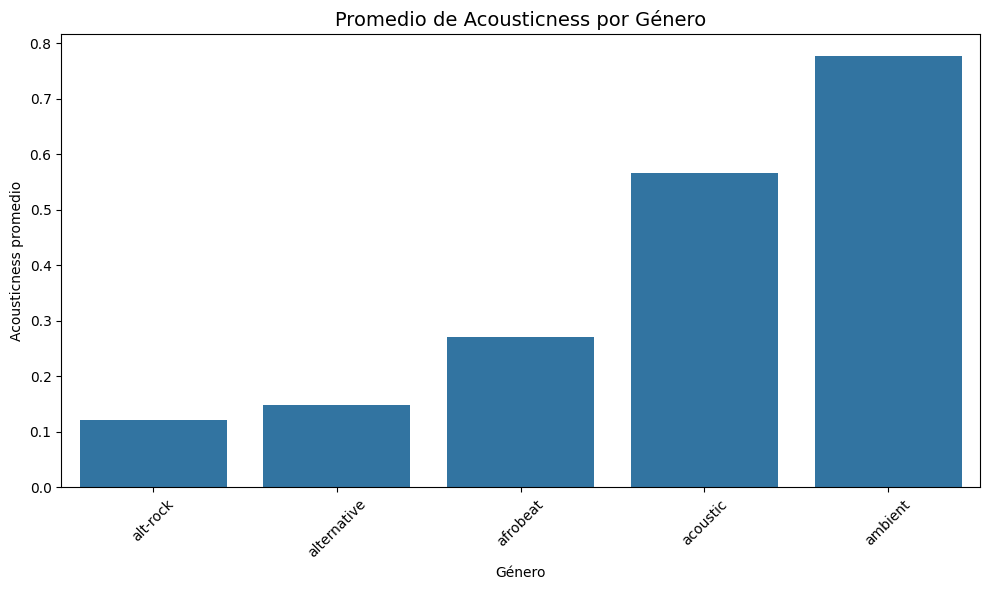

In [47]:
plt.figure(figsize=(10,6))

# Top 5 géneros más frecuentes
generos_top5 = df['track_genre'].value_counts().head(5).index

# Filtrar dataset
df_filtrado = df[df['track_genre'].isin(generos_top5)]

# Promedio de acousticness
promedios = df_filtrado.groupby('track_genre')['acousticness'].mean().sort_values()

sns.barplot(
    x=promedios.index,
    y=promedios.values
)

plt.title('Promedio de Acousticness por Género', fontsize=14)
plt.xlabel('Género')
plt.ylabel('Acousticness promedio')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### El gráfico muestra el nivel promedio de acousticness por género musical. Se observan diferencias claras entre géneros: aquellos con valores más altos presentan un sonido más acústico o natural, mientras que los géneros con valores más bajos tienden a ser más producidos electrónicamente. Esto evidencia que el tipo de instrumentación y producción varía según el género.

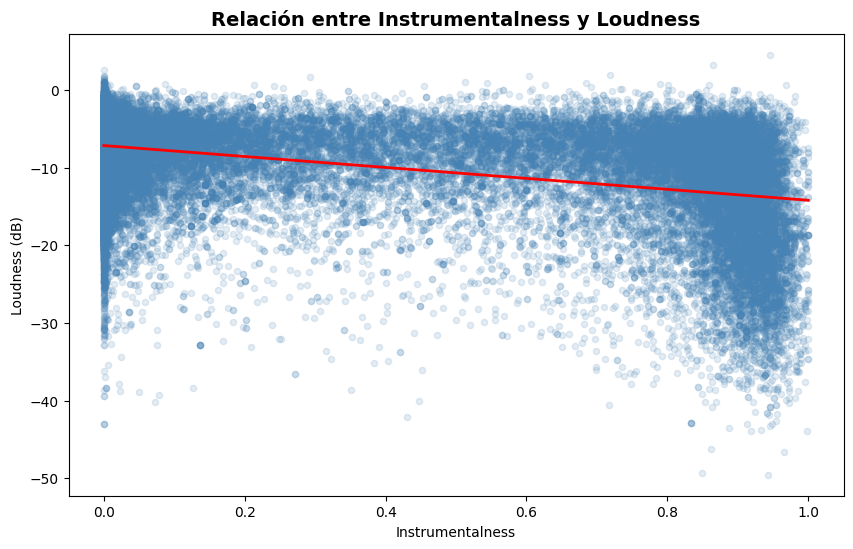

In [48]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='instrumentalness',
    y='loudness',
    scatter_kws={'alpha':0.15, 's':20, 'color':'steelblue'},
    line_kws={'color':'red', 'linewidth':2}
)

plt.title('Relación entre Instrumentalness y Loudness', fontsize=14, weight='bold')
plt.xlabel('Instrumentalness')
plt.ylabel('Loudness (dB)')

plt.show()

### Se observa una relación negativa moderada entre instrumentalness y loudness. Esto indica que, en promedio, las canciones con mayor contenido instrumental tienden a presentar niveles de volumen menores. Esto puede explicarse por estilos musicales más suaves o menos comprimidos en producción.

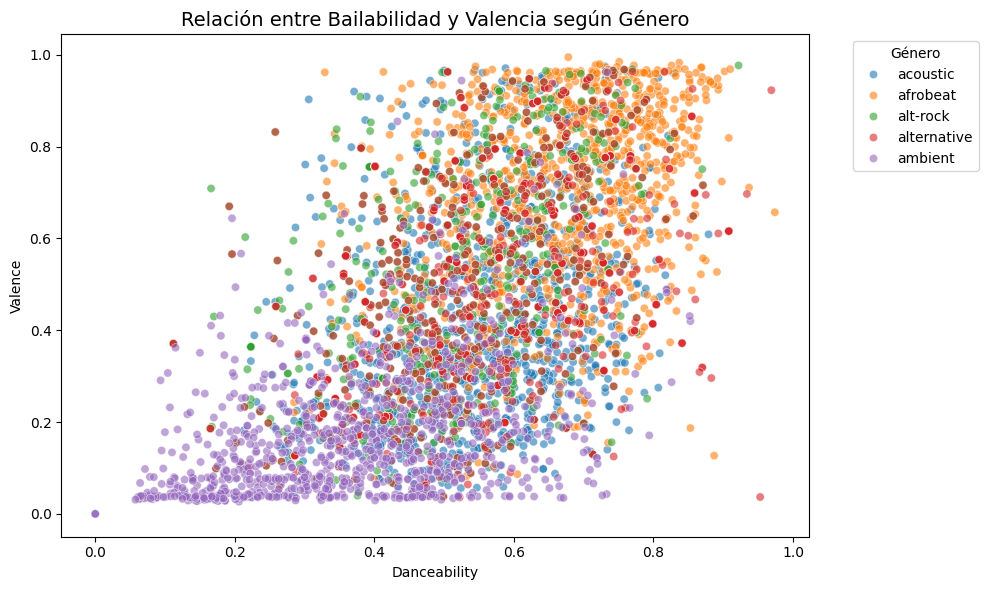

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtrado,
    x='danceability',
    y='valence',
    hue='track_genre',
    palette='tab10',
    alpha=0.6
)

plt.title('Relación entre Bailabilidad y Valencia según Género', fontsize=14)
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.legend(title='Género', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### Se observa una relación positiva entre danceability y valence, lo que indica que las canciones más bailables tienden a transmitir emociones más positivas. Además, se aprecian diferencias entre géneros en la distribución de estas variables.

### **CONCLUSIÓN GENERAL**

A partir del análisis de correlación y visualización de datos, se identificaron relaciones significativas entre diversas variables musicales. Se observó una fuerte relación positiva entre energía y volumen, indicando que canciones más intensas tienden a ser más ruidosas. Asimismo, se evidenció una relación negativa entre energía y acousticness, lo que sugiere que las canciones más energéticas suelen ser menos acústicas. Por otro lado, variables como instrumentalidad y volumen no presentan una relación significativa, lo que indica independencia entre estas características. Finalmente, se observaron diferencias entre géneros musicales, evidenciando que cada uno presenta patrones propios en términos de energía, emocionalidad y producción sonora.